## Student Performance Prediction

##### This project focuses on predicting whether a student will pass or fail an exam using Machine Learning techniques. The dataset contains information about students’ study hours, attendance percentage, and exam results.

##### The main objective is to build a classification model that can accurately predict student performance based on input features.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [32]:
file_path = 'Final_Marks_Data.csv'
df = pd.read_csv(file_path)

In [33]:
print(df.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100)  
0                  3                             72  
1                  3                             56  
2                  3                             56  
3                  3            

In [34]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None


In [35]:
print(df.isnull().sum())

Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


In [36]:
df.describe()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


In [37]:
df.duplicated().sum()

np.int64(0)

#### Preprocessing

In [38]:
df = df.dropna()

In [39]:
df['Result'] = df['Final Exam Marks (out of 100)'].apply(
    lambda x: 'Pass' if x >= 50 else 'Fail'
)

In [40]:
print(df.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100) Result  
0                  3                             72   Pass  
1                  3                             56   Pass  
2                  3                             56   Pass  
3   

In [41]:
# Features
X = df[[
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours'
]]

# Target
y = df['Result']

In [42]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9566666666666667


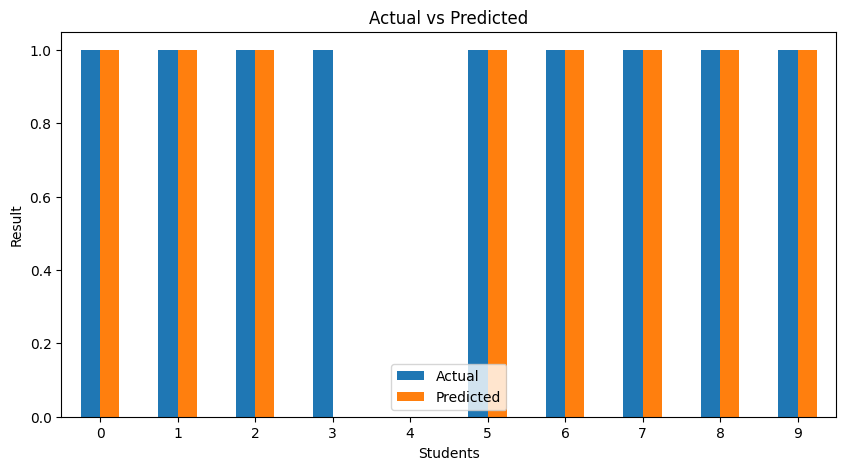

In [47]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10).plot(kind='bar', figsize=(10,5))

plt.title('Actual vs Predicted')
plt.xlabel('Students')
plt.ylabel('Result')
plt.xticks(rotation=0)

plt.show()

### Result Interpretation

##### The Logistic Regression model successfully learned the relationship between study hours, attendance percentage, and exam outcomes.
##### Students with higher study hours and better attendance had a greater probability of passing the exam.
##### The model achieved high accuracy, indicating that the selected features are useful for predicting student performance.

### Improvements

#### Possible future improvements:

##### Add more features such as assignment marks and quiz scores.
##### Compare multiple ML algorithms like KNN and Decision Tree.
##### Use larger datasets for better accuracy.
##### Create an interactive dashboard using Streamlit.